In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn import preprocessing

1.DATA CLEANING

In [5]:
data=pd.read_csv("diabet.csv")

In [6]:
from google.colab import files

# Upload the file
uploaded = files.upload()

# Check if the file was uploaded
for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')

# After uploading, you can run the cell that reads the CSV file again.

Saving diabet.csv to diabet (1).csv
User uploaded file "diabet (1).csv"


In [7]:
data['Gender'] = data['Gender'].map({'F': 0, 'M': 1})

In [8]:
data.drop(columns=['Unnamed: 0'],axis=1,inplace=True)

In [9]:
data.isnull().sum()

,0
Age,0
Gender,1
BMI,0
Chol,0
TG,0
HDL,0
LDL,0
Cr,0
BUN,0
Diagnosis,0


In [10]:
data.dropna(inplace=True)

In [11]:
data

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,50,0.0,24,4.20,0.90,2.40,1.40,46.0,4.70,0
1,26,1.0,23,3.70,1.40,1.10,2.10,62.0,4.50,0
2,33,1.0,21,4.90,1.00,0.80,2.00,46.0,7.10,0
3,45,0.0,21,2.90,1.00,1.00,1.50,24.0,2.30,0
4,50,0.0,24,3.60,1.30,0.90,2.10,50.0,2.00,0
...,...,...,...,...,...,...,...,...,...,...
5127,54,1.0,23,5.00,1.50,1.24,2.98,77.0,3.50,1
5128,50,0.0,22,4.37,2.09,1.37,2.29,47.3,4.40,1
5129,67,1.0,24,3.89,1.38,1.14,2.17,70.6,4.73,1
5130,60,0.0,29,5.91,1.29,1.73,2.85,50.2,7.33,1


In [12]:
data.describe()

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
count,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000,5131.000000
mean,48.949133,0.634574,24.611772,4.866779,1.719351,1.593303,2.914084,71.152040,4.897124,0.388228
std,14.049909,0.481596,4.276019,1.001122,1.327186,1.038950,0.945512,28.492451,1.689334,0.487395
min,20.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.300000,4.860753,0.500000,0.000000
25%,36.000000,0.000000,22.000000,4.190000,0.910000,1.090000,2.290000,58.000000,3.900000,0.000000
50%,49.000000,1.000000,24.000000,4.800000,1.380000,1.300000,2.790000,70.200000,4.720000,0.000000
75%,59.000000,1.000000,27.000000,5.460000,2.100000,1.590000,3.400000,81.600000,5.600000,1.000000
max,93.000000,1.000000,47.000000,11.650000,32.640000,9.900000,9.900000,800.000000,38.900000,1.000000


2.DATA VISUALIZATION

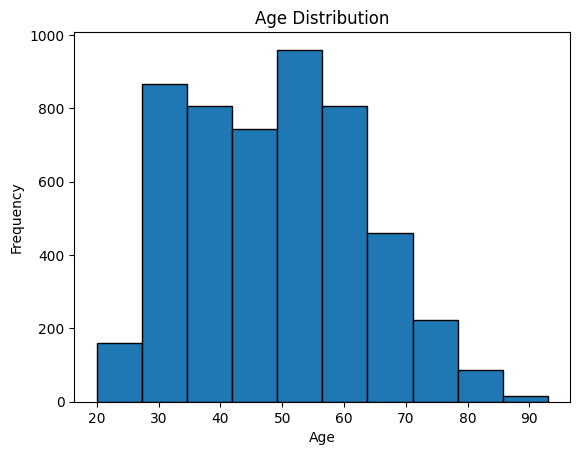

In [13]:
plt.hist(data['Age'], bins=10, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Age Distribution')
plt.show()

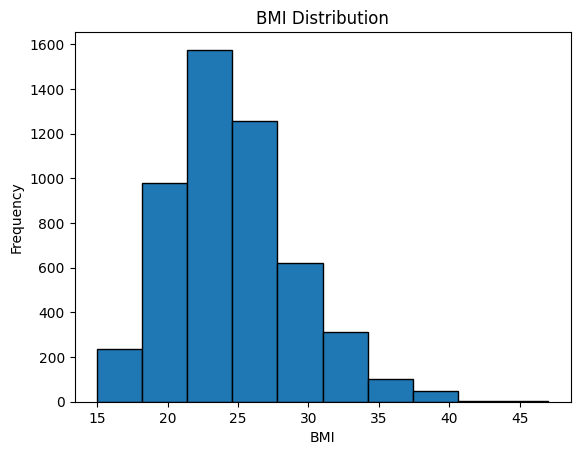

In [14]:
plt.hist(data['BMI'], bins=10, edgecolor='black')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.title('BMI Distribution')
plt.show()

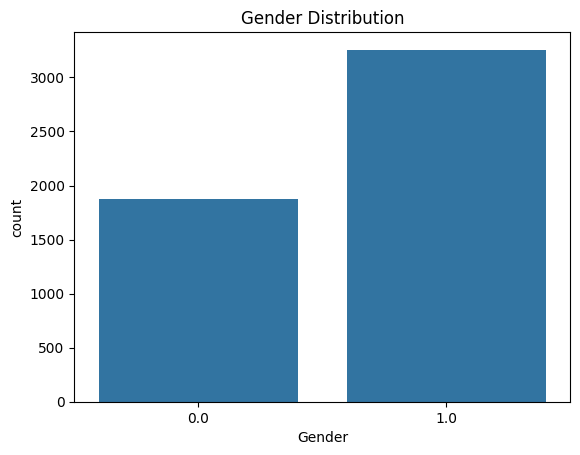

In [15]:
sns.countplot(data=data, x='Gender')
plt.title('Gender Distribution')
plt.show()

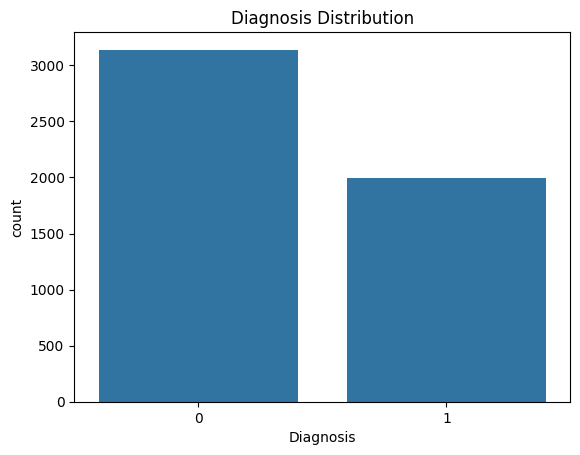

In [16]:
sns.countplot(data=data, x='Diagnosis')
plt.title('Diagnosis Distribution')
plt.show()

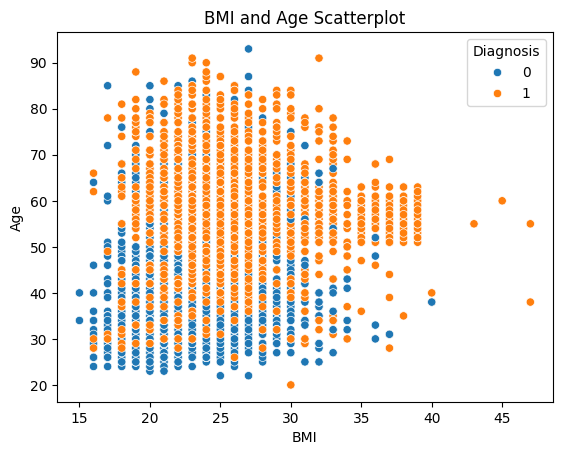

In [17]:
sns.scatterplot(data=data,x="BMI",y="Age" ,hue="Diagnosis")
plt.title('BMI and Age Scatterplot')

plt.show()

3.PREDICTIVE ANALYTICS ALGORITHMS

KNeighborsClassifier Accuracy Test

In [18]:
data_copy =data.copy()
data_copy

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,50,0.0,24,4.20,0.90,2.40,1.40,46.0,4.70,0
1,26,1.0,23,3.70,1.40,1.10,2.10,62.0,4.50,0
2,33,1.0,21,4.90,1.00,0.80,2.00,46.0,7.10,0
3,45,0.0,21,2.90,1.00,1.00,1.50,24.0,2.30,0
4,50,0.0,24,3.60,1.30,0.90,2.10,50.0,2.00,0
...,...,...,...,...,...,...,...,...,...,...
5127,54,1.0,23,5.00,1.50,1.24,2.98,77.0,3.50,1
5128,50,0.0,22,4.37,2.09,1.37,2.29,47.3,4.40,1
5129,67,1.0,24,3.89,1.38,1.14,2.17,70.6,4.73,1
5130,60,0.0,29,5.91,1.29,1.73,2.85,50.2,7.33,1


In [19]:
X = data_copy.drop(columns=['Diagnosis'])

In [20]:
y = data_copy['Diagnosis'].values

In [21]:
KNeighborsClassifier()

KNeighborsClassifier()

In [22]:
knn = KNeighborsClassifier(n_neighbors = 25)
knn.fit(X,y)

KNeighborsClassifier(n_neighbors=25)

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=1,stratify=y)

In [24]:
knn = KNeighborsClassifier(n_neighbors = 23)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=23)

In [25]:
knn.score(X_train,y_train)

0.8140838206627681

In [26]:
knn.score(X_test,y_test)

0.7916260954235638

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

In [28]:
from sklearn.model_selection import cross_val_score

In [29]:
knn = KNeighborsClassifier(n_neighbors=25)
scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
print(scores.mean())

0.7965426384190849


In [30]:
scores

array([0.77615572, 0.80048662, 0.81265207, 0.78588808, 0.80487805,
       0.81463415, 0.76097561, 0.8097561 , 0.82439024, 0.77560976])

In [31]:
CVAccuracy=[]
for j in range(1,26):
    knn = KNeighborsClassifier(n_neighbors = j)
    scores = cross_val_score(knn, X_train, y_train, cv=10, scoring='accuracy')
    CVAccuracy.append([scores.mean(),j])
data_copy = pd.DataFrame (CVAccuracy,columns=['Validation Accuracy','NeighbourSize'])
print(data_copy)

    Validation Accuracy  NeighbourSize
0              0.760489              1
1              0.753419              2
2              0.772898              3
3              0.764133              4
4              0.780705              5
5              0.777054              6
6              0.790695              7
7              0.788260              8
8              0.791181              9
9              0.782165             10
10             0.790210             11
11             0.787770             12
12             0.791181             13
13             0.788505             14
14             0.791184             15
15             0.789716             16
16             0.792882             17
17             0.795805             18
18             0.796293             19
19             0.793372             20
20             0.794590             21
21             0.794831             22
22             0.795809             23
23             0.792399             24
24             0.796543  

In [32]:
kfoldCV = data_copy.groupby("NeighbourSize")
kfoldCV = kfoldCV.mean()
kfoldCV = kfoldCV.reset_index()
kfoldCV[['NeighbourSize', 'Validation Accuracy']]

,NeighbourSize,Validation Accuracy
0,1,0.760489
1,2,0.753419
2,3,0.772898
3,4,0.764133
4,5,0.780705
5,6,0.777054
6,7,0.790695
7,8,0.788260
8,9,0.791181
9,10,0.782165


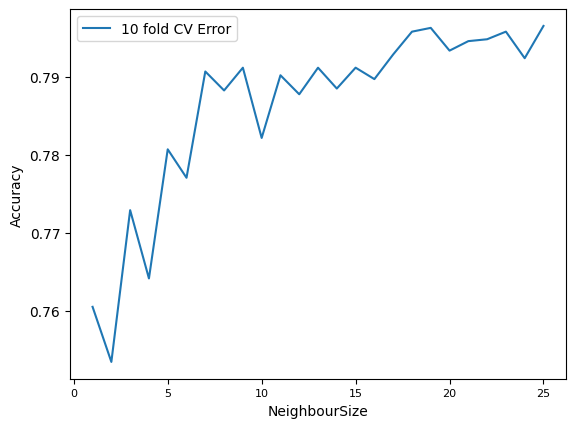

In [33]:
fig=plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(kfoldCV['NeighbourSize'].values,kfoldCV['Validation Accuracy'].values,label = '10 fold CV Error')
ax.set_xlabel('NeighbourSize')
ax.set_ylabel('Accuracy')
ax.tick_params(axis='x', labelsize=8)
ax.legend(loc='best')

In [34]:
knn = KNeighborsClassifier(n_neighbors=25)
knn.fit(X_train,y_train)
knn.score(X_test,y_test)

0.7945472249269717

DecisionTreeClassifier Accuracy Test

In [35]:
data_copy2=data.copy()
data_copy2

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,50,0.0,24,4.20,0.90,2.40,1.40,46.0,4.70,0
1,26,1.0,23,3.70,1.40,1.10,2.10,62.0,4.50,0
2,33,1.0,21,4.90,1.00,0.80,2.00,46.0,7.10,0
3,45,0.0,21,2.90,1.00,1.00,1.50,24.0,2.30,0
4,50,0.0,24,3.60,1.30,0.90,2.10,50.0,2.00,0
...,...,...,...,...,...,...,...,...,...,...
5127,54,1.0,23,5.00,1.50,1.24,2.98,77.0,3.50,1
5128,50,0.0,22,4.37,2.09,1.37,2.29,47.3,4.40,1
5129,67,1.0,24,3.89,1.38,1.14,2.17,70.6,4.73,1
5130,60,0.0,29,5.91,1.29,1.73,2.85,50.2,7.33,1


In [36]:
X = data_copy2[['TG','BMI']]
y = data_copy2['Diagnosis']

In [37]:
X_train, X_test , y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1,stratify=y)

In [38]:
DecisionTreeClassifier()

DecisionTreeClassifier()

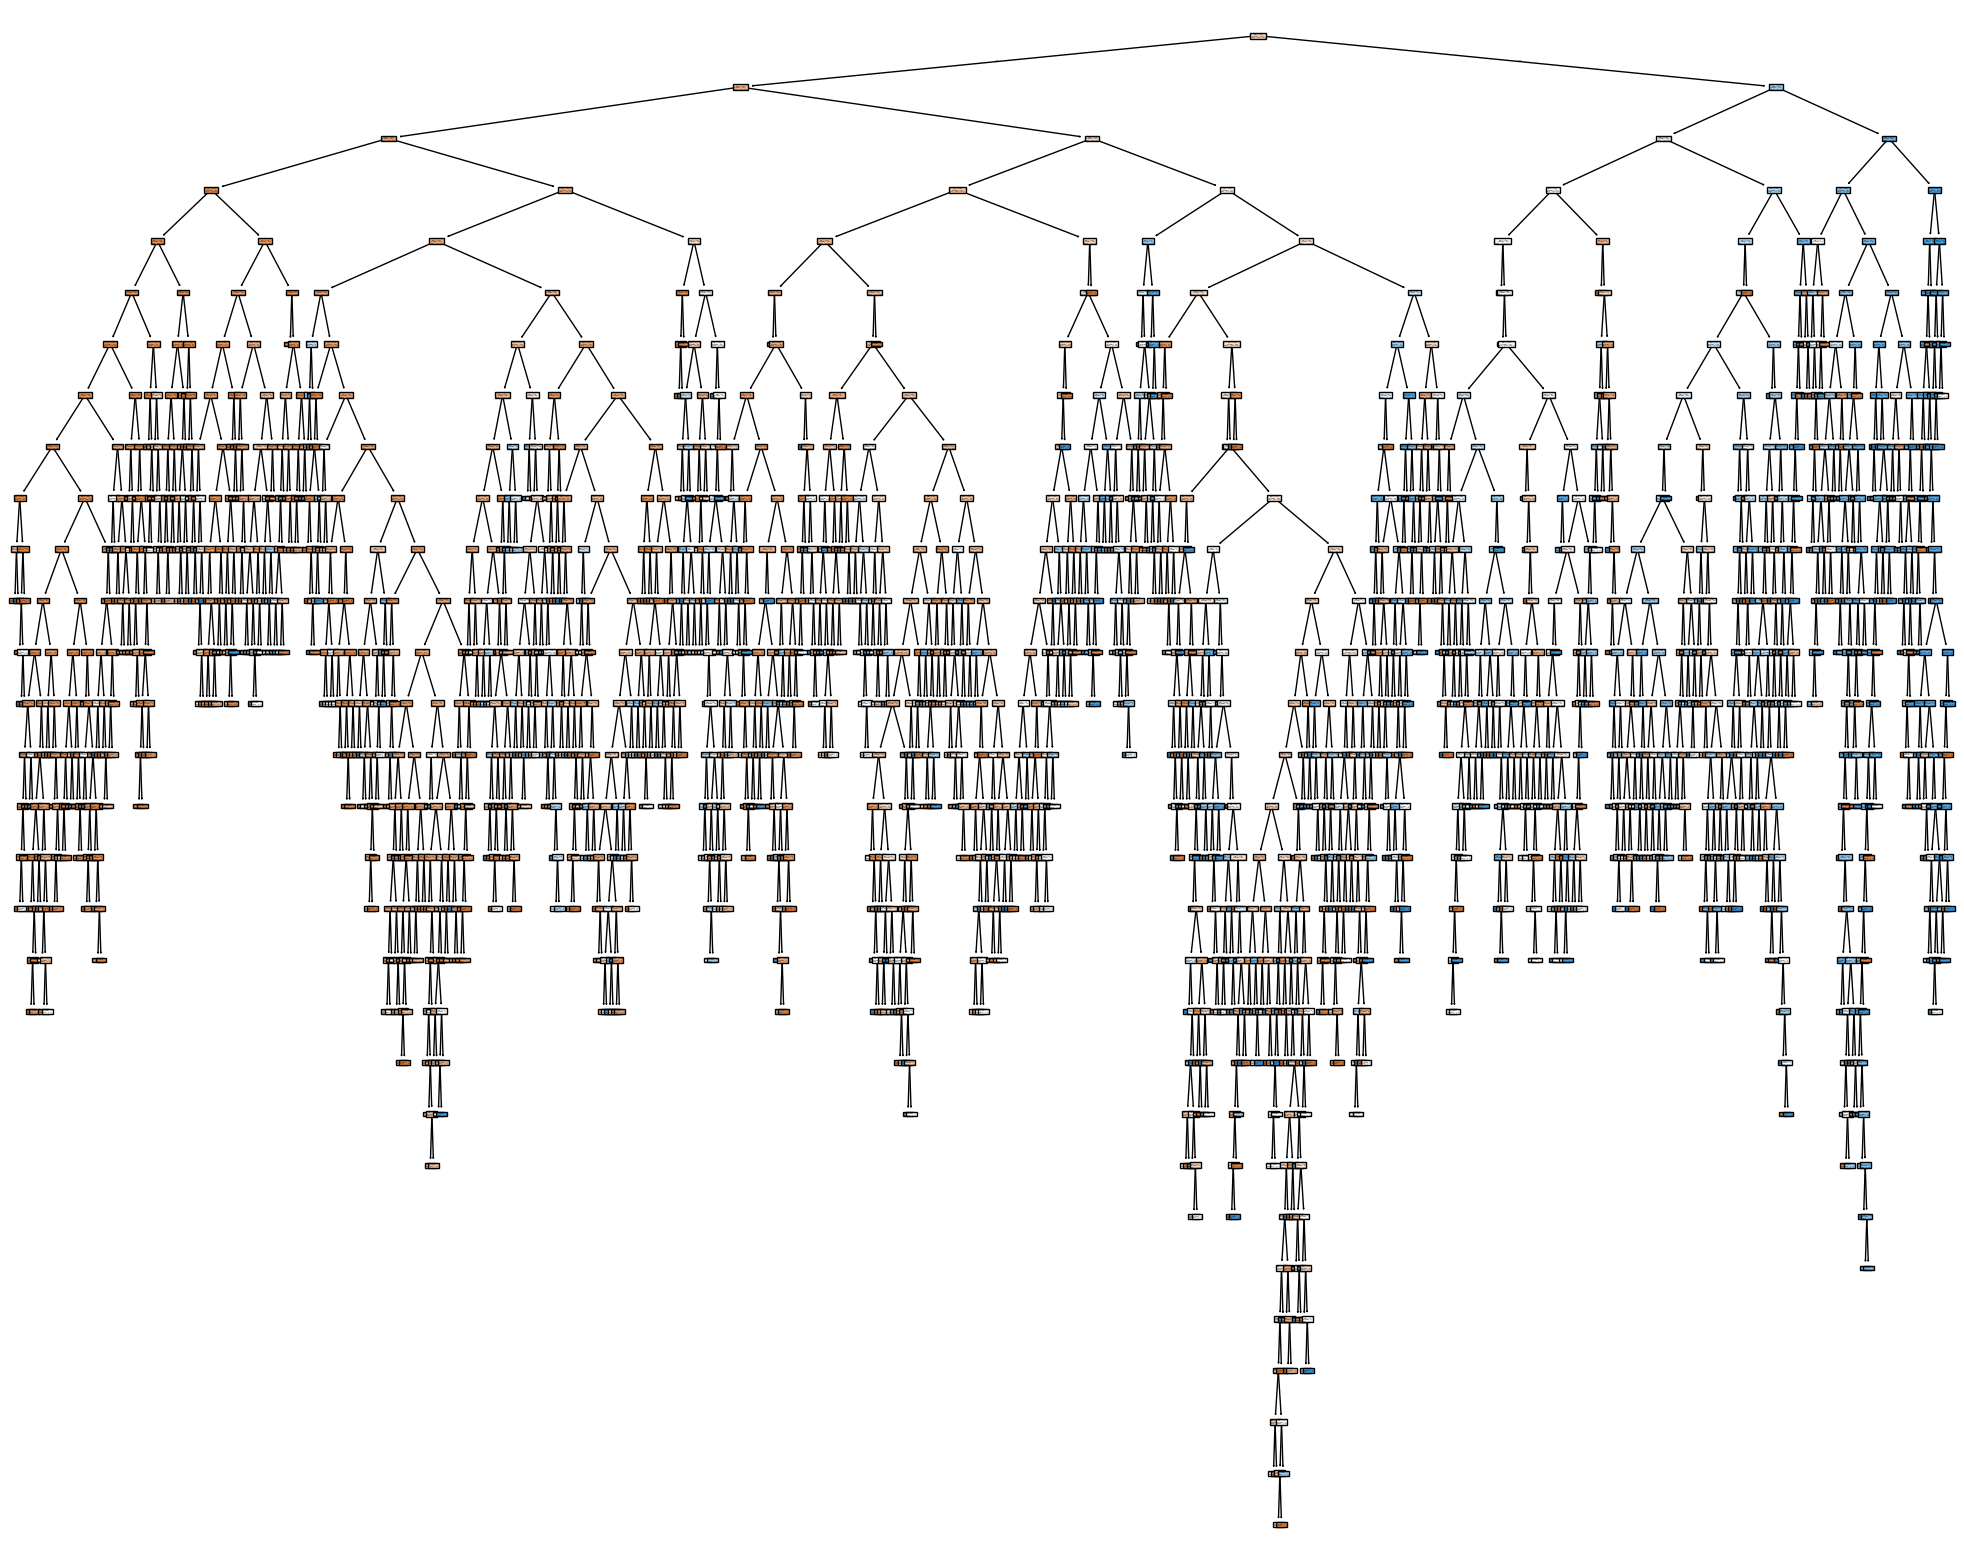

In [39]:
classifier = DecisionTreeClassifier()
classifier.fit(X_train, y_train)
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, feature_names=['TG','BMI'], filled=True)

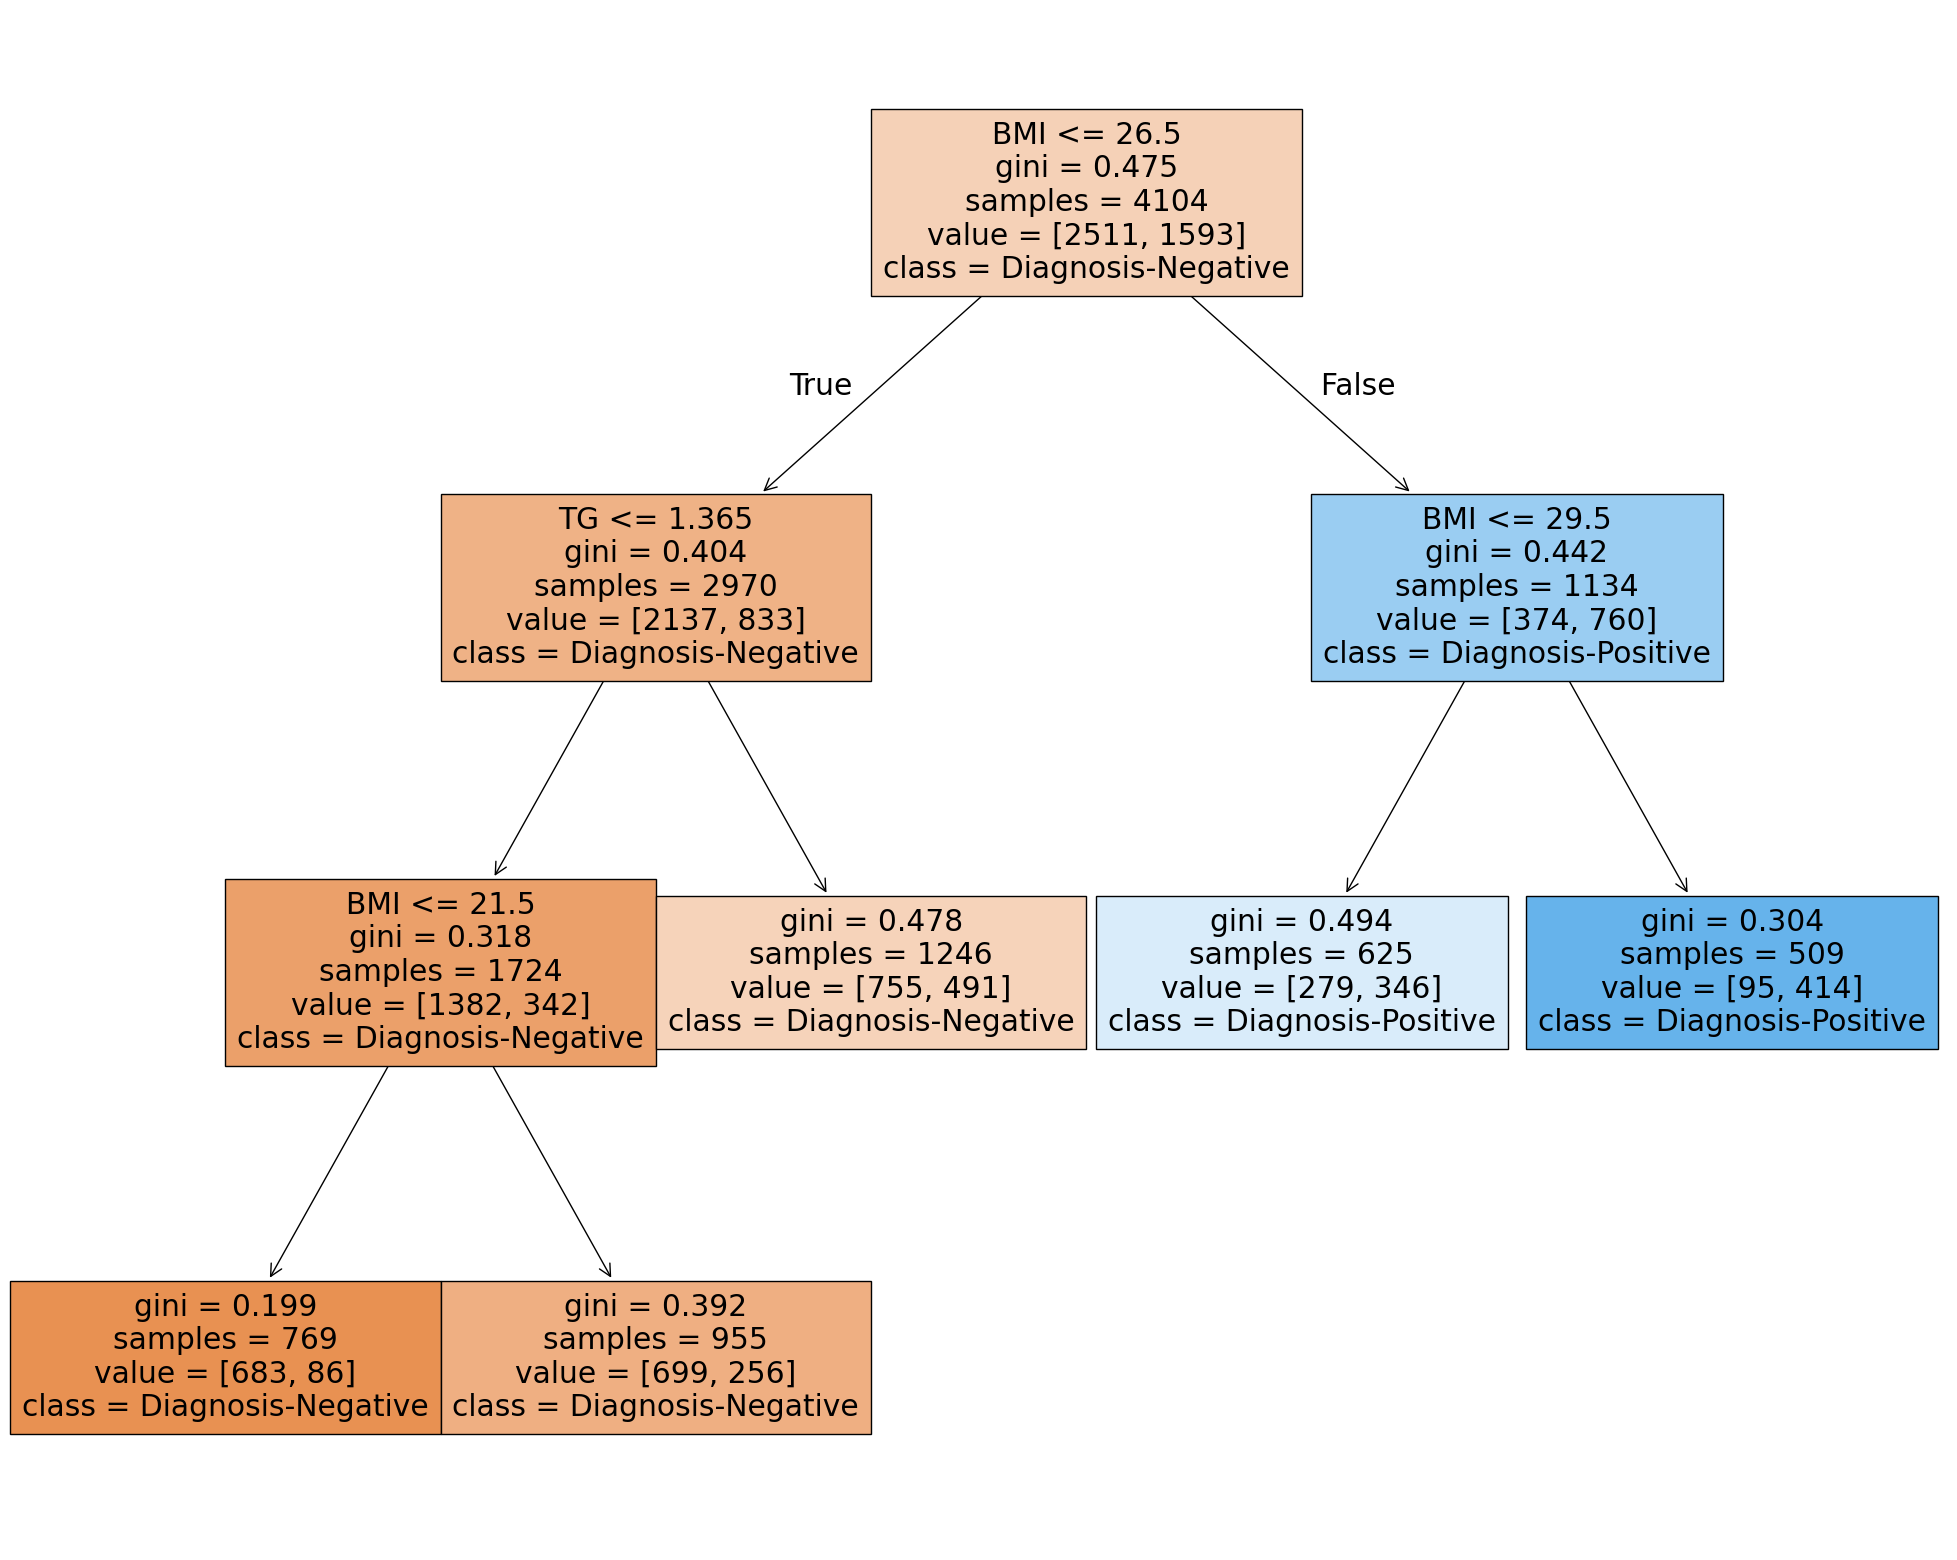

In [40]:
classifier = DecisionTreeClassifier(ccp_alpha=0.005)
classifier.fit(X_train, y_train)
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, class_names=['Diagnosis-Negative','Diagnosis-Positive'],feature_names=['TG','BMI'], filled=True)

In [41]:
y_pred = classifier.predict(X_test)
accuracy_score(y_test,y_pred)

0.7098344693281402

In [42]:
comp=pd.DataFrame({'Actual':y_test, 'Predicted':y_pred})
comp = pd.concat([X_test.reset_index(drop=True), comp.reset_index(drop=True)], axis= 1)
comp

,TG,BMI,Actual,Predicted
0,3.70,27,0,1
1,1.53,20,0,0
2,1.31,23,0,0
3,1.61,27,0,1
4,3.98,28,1,1
...,...,...,...,...
1022,3.99,29,1,1
1023,2.33,25,1,0
1024,2.00,35,1,1
1025,1.45,21,0,0


In [43]:
y_predprobs = classifier.predict_proba(X_test)
y_predprobs

array([[0.4464    , 0.5536    ],
       [0.605939  , 0.394061  ],
       [0.73193717, 0.26806283],
       ...,
       [0.18664047, 0.81335953],
       [0.605939  , 0.394061  ],
       [0.88816645, 0.11183355]])

In [44]:
classifier = DecisionTreeClassifier()
path = classifier.cost_complexity_pruning_path(X_train, y_train)
path

{'ccp_alphas': array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.80154089e-07,
        1.47675586e-06, 1.58223842e-06, 2.70738575e-06, 5.80154089e-06,
        5.80154089e-06, 5.80154089e-06, 5.80154089e-06, 5.80154089e-06,
        6.64540138e-06, 6.76846437e-06, 6.96184907e-06, 6.96184907e-06,
        8.12215724e-06, 8.12215724e-06, 8.12215724e-06, 8.70231133e-06,
        8.70231133e-06, 1.21832359e-05, 1.23766206e-05, 1.35369287e-05,
        1.35369287e-05, 1.54707757e-05, 1.54707757e-05, 1.62443145e-05,
        1.62443145e-05, 1.62443145e-05, 1.62443145e-05, 1.62443145e-05,
        1.62443145e-05, 1.62443145e-05, 1.62443145

In [45]:
from sklearn.model_selection import KFold
cv = KFold(n_splits=5, random_state=10, shuffle=True)
CVErrors=[]
for i in path.ccp_alphas:
    for train_index, validation_index in cv.split(X_train):
        X_trainp, X_valid = X_train.iloc[train_index], X_train.iloc[validation_index]
        y_trainp, y_valid = y_train.iloc[train_index], y_train.iloc[validation_index]
        classifier = DecisionTreeClassifier(ccp_alpha=i)
        classifier.fit(X_trainp, y_trainp)
        y_pred=classifier.predict(X_valid)
        CVErrors.append([i,accuracy_score(y_trainp, classifier.predict(X_trainp)),accuracy_score(y_valid, y_pred)])
data_copy2 = pd.DataFrame(CVErrors,columns=['alpha','Training Accuracy','Validation Accuracy'])
kfoldCV_by_alpha = data_copy2.groupby('alpha')
kfoldCV_by_alpha = kfoldCV_by_alpha.mean()
kfoldCV_by_alpha = kfoldCV_by_alpha.reset_index()
kfoldCV_by_alpha

,alpha,Training Accuracy,Validation Accuracy
0,0.000000e+00,0.887914,0.683407
1,5.801541e-07,0.887914,0.684446
2,1.476756e-06,0.887914,0.682009
3,1.582238e-06,0.887914,0.682983
4,2.707386e-06,0.887914,0.682740
...,...,...,...
390,2.370960e-03,0.705896,0.700768
391,5.066872e-03,0.704860,0.701987
392,9.224660e-03,0.704860,0.701987
393,1.349700e-02,0.704860,0.701987


In [46]:
kfoldCV_by_alpha=kfoldCV_by_alpha.sort_values(by=['Validation Accuracy'],ascending=False)
kfoldCV_by_alpha

,alpha,Training Accuracy,Validation Accuracy
381,0.000782,0.724537,0.703206
383,0.000842,0.720455,0.702718
379,0.000740,0.726059,0.702475
380,0.000745,0.726059,0.702475
378,0.000719,0.726059,0.702475
...,...,...,...
135,0.000104,0.886391,0.678842
111,0.000084,0.887487,0.678841
141,0.000108,0.886208,0.678597
134,0.000102,0.886452,0.678597


Test Accuracy: 0.7166504381694255


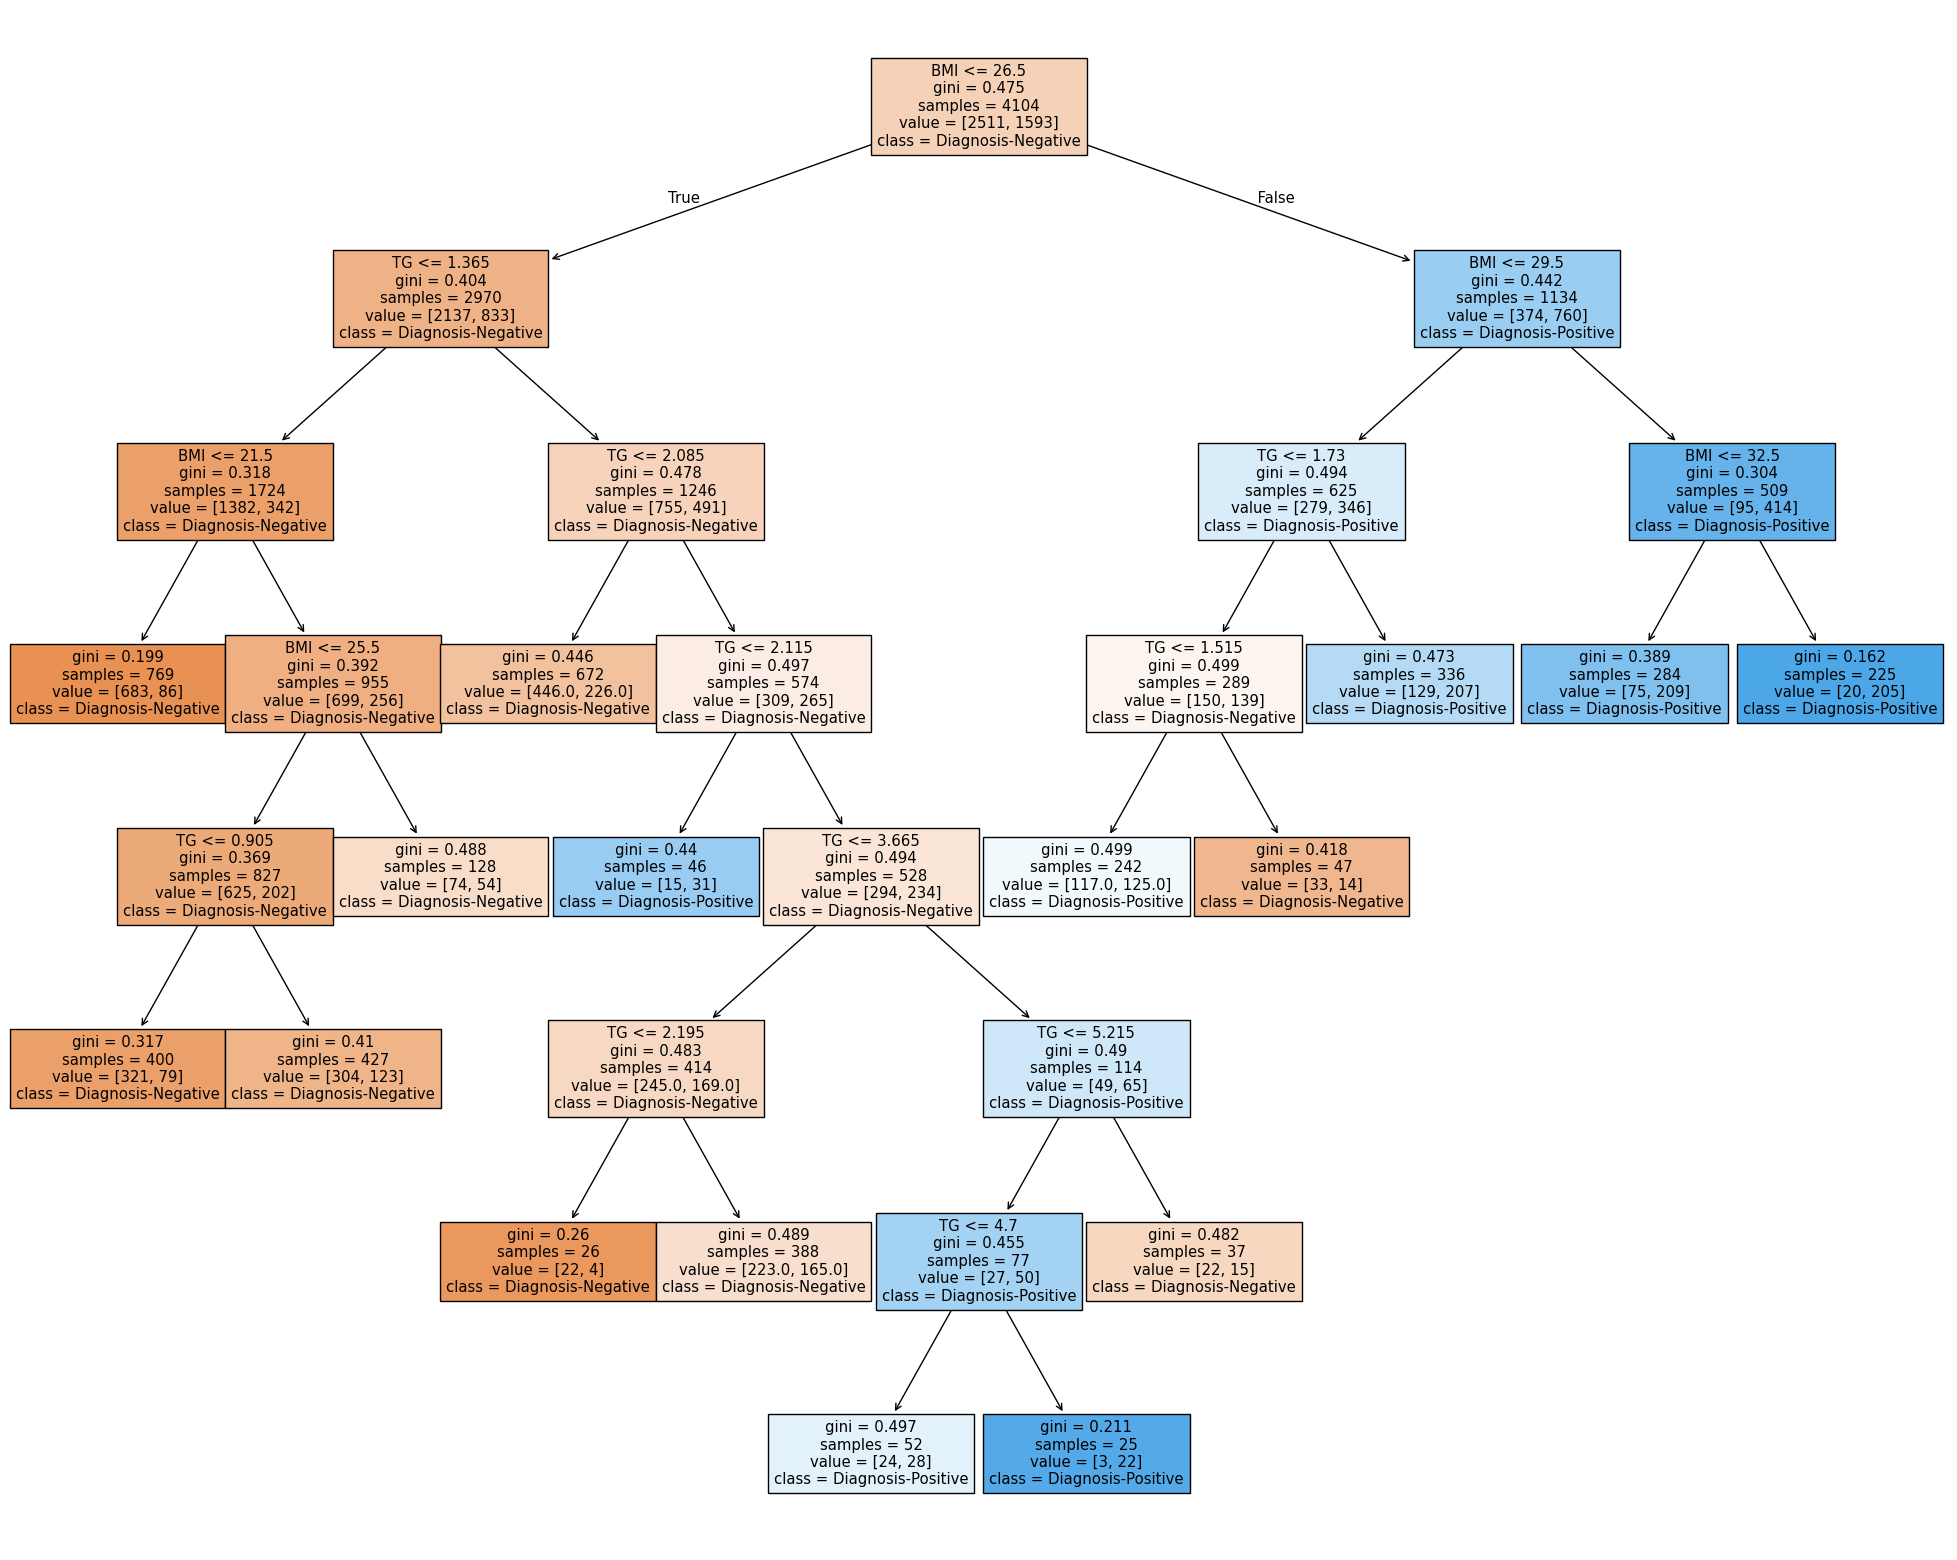

In [47]:
classifier = DecisionTreeClassifier(ccp_alpha=0.000782)
classifier.fit(X_train, y_train)
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(classifier, class_names=['Diagnosis-Negative','Diagnosis-Positive'],feature_names=['TG','BMI'], filled=True)
y_pred = classifier.predict(X_test)
print('Test Accuracy:', accuracy_score(y_test, y_pred))

LogisticRegression Accuracy Test

In [48]:
data_copy3=data.copy()
data_copy3

,Age,Gender,BMI,Chol,TG,HDL,LDL,Cr,BUN,Diagnosis
0,50,0.0,24,4.20,0.90,2.40,1.40,46.0,4.70,0
1,26,1.0,23,3.70,1.40,1.10,2.10,62.0,4.50,0
2,33,1.0,21,4.90,1.00,0.80,2.00,46.0,7.10,0
3,45,0.0,21,2.90,1.00,1.00,1.50,24.0,2.30,0
4,50,0.0,24,3.60,1.30,0.90,2.10,50.0,2.00,0
...,...,...,...,...,...,...,...,...,...,...
5127,54,1.0,23,5.00,1.50,1.24,2.98,77.0,3.50,1
5128,50,0.0,22,4.37,2.09,1.37,2.29,47.3,4.40,1
5129,67,1.0,24,3.89,1.38,1.14,2.17,70.6,4.73,1
5130,60,0.0,29,5.91,1.29,1.73,2.85,50.2,7.33,1


In [49]:
X = data_copy3.drop('Diagnosis',axis=1)
y = data_copy3['Diagnosis']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
scaler = preprocessing.StandardScaler()
scaler.fit(X_train)
X_trainStandard = scaler.transform(X_train)
X_testStandard = scaler.transform(X_test)

In [51]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
C_param_range = [0.001,0.01,0.1,1,10,100,1000,10000]
scoresCV = []
for c in C_param_range:
    logreg = LogisticRegression(C=c,penalty='l1',max_iter=1000,solver='liblinear')
    pipe = make_pipeline(preprocessing.StandardScaler(), logreg)
    scoreCV = cross_val_score(pipe, X_train, y_train, scoring='accuracy',
                             cv=KFold(n_splits=10, shuffle=True,
                                            random_state=1))
    scoresCV.append([c,np.mean(scoreCV)])

In [52]:
data_copy3 = pd.DataFrame(scoresCV,columns=['C (1/lambda)','Validation Accuracy'])
data_copy3

,C (1/lambda),Validation Accuracy
0,0.001,0.611854
1,0.010,0.811883
2,0.100,0.814558
3,1.000,0.816022
4,10.000,0.816023
5,100.000,0.816023
6,1000.000,0.816023
7,10000.000,0.816023


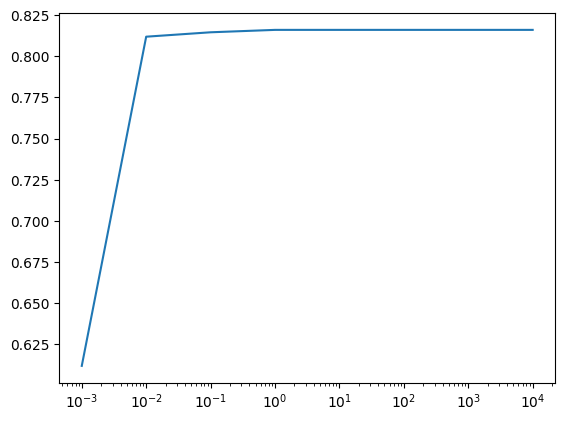

In [53]:
ax = plt.gca()
ax.plot(data_copy3['C (1/lambda)'].values,data_copy3['Validation Accuracy'].values)
ax.set_xscale('log')

In [54]:
logreg = LogisticRegression(C=10,penalty='l1',max_iter=1000,solver='liblinear')
logreg.fit(X_trainStandard, y_train)
score = logreg.score(X_testStandard, y_test)
print('Test Accuracy:', score)
Model_intercept = pd.DataFrame({"Variables":'Intercept',"Coefficients":logreg.intercept_[0]},index=[0])
Model_coefficients = pd.DataFrame({"Variables":X.columns,"Coefficients":np.transpose(logreg.coef_[0])})
Model_coefficients = pd.concat([Model_intercept,Model_coefficients]).reset_index(drop=True)
print(Model_coefficients)

Test Accuracy: 0.8120740019474196
   Variables  Coefficients
0  Intercept     -0.687487
1        Age      1.254252
2     Gender     -0.150419
3        BMI      1.045573
4       Chol     -0.266466
5         TG      0.359119
6        HDL      0.958970
7        LDL      0.196408
8         Cr     -0.240708
9        BUN      0.203840


4.Project Report

This is a data analysis project. The data I have is a database containing the results of diabetes diagnosis of 5132 people based on 9 different variables. The 9 variables that affect the diagnosis of diabetes are as follows.

Age: Represents the age of the patient in years.

Gender: Indicates the gender of the patient, which can be a factor in the prediction of diabetes.

Body Mass Index (BMI): BMI is a measure that uses a person's height and weight to determine whether they are in the normal weight, overweight, or obese category.

Chol: total cholesterol level in the blood.

TG (Triglycerides): Represents the level of triglycerides in the blood.

HDL (High-Density Lipoprotein): Is the "good" cholesterol that helps transport excess cholesterol from body tissues back to the liver for further processing or excretion.

LDL (Low-Density Lipoprotein): Is the "bad" cholesterol that can cause plaque buildup in the arteries, increasing the risk of heart disease and stroke.

Cr (Creatinine): A waste product of muscle metabolism that is excreted from the body through the kidneys.

BUN (Blood Urea Nitrogen): Is a measure used to evaluate kidney and liver function.

In the first part of the project, I started with data cleaning. There was missing gender information in a single row and I deleted that row from my data and there was a functionless column named Unnamed: 0 and I delete that column. Then I moved on to the data visualization part, which is the second part of my project. The third part of the project is using predictive analytics algorithms. I chose three of predictive analytics algorithms that are Kneighbors classifier, Decisiontree classifier and Logistic regression. The results of the predictive analytics algorithms are

Kneighbors classifier: 0.7945472249269717 Accuracy.
Decisiontree classifier: 0.7166504381694255 Accuracy.
Logistic regression: 0.8120740019474196 Accuracy.

Logistic regression gave a better result than the other two, but since this is diagnosing a life-threatening disease, 81 percent may not be very useful, although it is a good result. Although there is no accuracy rate that can be used directly for hospitals, people with a health report can see whether they have diabetes with 81 percent accuracy without going to the hospital, and this may help people go to the hospital and have more realistic tests, and this analysis can play an important role in early diagnosis.